# Stationary and Non-Stationary Processes

Notebook 06 distinguished a stochastic process from one observed history. To compare observations across dates, I now ask whether the process has stable population properties. Stationarity concerns that stability; ergodicity concerns what can be learned from a sufficiently long history.

I first establish stationarity and ergodicity, then contrast deterministic trends and random walks before distinguishing stationary noise assumptions. A unit-root example connects the hypothesis-testing framework of Notebook 03 with time-series assumptions. The Wold representation closes the notebook by connecting stationary processes with the linear models in Notebook 08.

In [1]:
from pathlib import Path
import sys
repository = Path.cwd()
if not (repository / "src" / "finstats").is_dir():
    repository = repository.parent
if not (repository / "src" / "finstats").is_dir():
    raise RuntimeError("Run from the repository root or notebooks directory")
sys.path.insert(0, str(repository / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

plt.rcParams.update({
    "figure.figsize": (7,4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 11, "axes.titlesize": 12,
    "legend.frameon": False, "lines.linewidth": 1.8,
})

from statsmodels.tsa.stattools import adfuller
from finstats.simulation import simulate_random_walk


## 1. Stationarity and Ergodicity

Finite second moments alone do not establish stationarity. A random walk has finite variance at each finite date, yet that variance grows with time. Weak stationarity additionally requires a constant mean and autocovariance depending only on lag. These stable quantities make population comparisons across dates meaningful, while dependence can remain.

### Strict and Second-order Stationarity

**Definition: strict stationarity.** Strict stationarity requires, for every finite set of dates and time shift $h$,
$$F_{Y_{t_1},\ldots,Y_{t_k}}(y)=F_{Y_{t_1+h},\ldots,Y_{t_k+h}}(y).$$
**Definition: second-order stationarity.** Weak or covariance stationarity requires finite second moments and
$$E[Y_t]=\mu,\qquad\operatorname{Cov}(Y_t,Y_{t-j})=\gamma_j.$$
Thus variance is constant at $\gamma_0$ and $\rho_j=\gamma_j/\gamma_0$. Strict stationarity with finite second moments implies weak stationarity. The reverse does not generally hold.

### Ergodicity

**Definition: moment ergodicity.** Following the course framing, a stationary process is ergodic for the moments used here when the sample moments converge in probability to their population counterparts under the relevant conditions: 
$$\bar Y\xrightarrow{P}\mu,\qquad\hat\gamma_j\xrightarrow{P}\gamma_j,\qquad\hat\rho_j\xrightarrow{P}\rho_j.$$
Stationarity concerns stability across time. Ergodicity concerns what a long single history reveals about the population. These are separate properties. Convergence of the displayed moments is the aspect needed here, rather than a general characterization of every form of ergodicity.



## 2. Non-Stationary Processes

Non-stationarity means that distributional properties are not invariant to time shifts. A changing mean or variance already rules out second-order stationarity.

### Deterministic Linear Trend

**Definition: deterministic linear trend.** A linear trend model is
$$Y_t=\beta_0+\beta_1t+\varepsilon_t,\qquad\varepsilon_t\sim WN(0,\sigma^2).$$
Its mean is $\beta_0+\beta_1t$, while variance is $\sigma^2$. With a stationary error process, removing the deterministic trend leaves a stationary process. Shocks are deviations around a fixed trend rather than permanent additions to its level.

### Random Walk and Drift

**Definition: random walk.** Starting at a fixed $Y_0=y_0$, a random walk accumulates successive shocks:
$$Y_t=Y_{t-1}+\varepsilon_t=y_0+\sum_{i=1}^t\varepsilon_i.$$
Uncorrelated mean-zero shocks give
$$E[Y_t]=y_0,\quad\operatorname{Var}(Y_t)=t\sigma^2,\quad
\operatorname{Cov}(Y_t,Y_s)=\sigma^2\min(t,s).$$
The covariance counts the shocks shared by the two sums. Variance grows with time, so a constant mean does not make the random walk stationary.

With drift, $Y_t=Y_{t-1}+\delta+\varepsilon_t$ has mean $y_0+\delta t$ and the same growing variance. Removing its expected linear trend still leaves a random walk. This distinguishes a stochastic trend from a trend-stationary process.

For illustration, I use $n=300$, $y_0=10$, $\beta_0=10$, $\beta_1=.1$ and innovation SD $.5$, using seed 506 and five histories per case. The drift illustration uses $\delta=.1$. The same IID Gaussian shocks appear as stationary noise and drive all three non-stationary constructions. This makes their different accumulation mechanisms comparable.

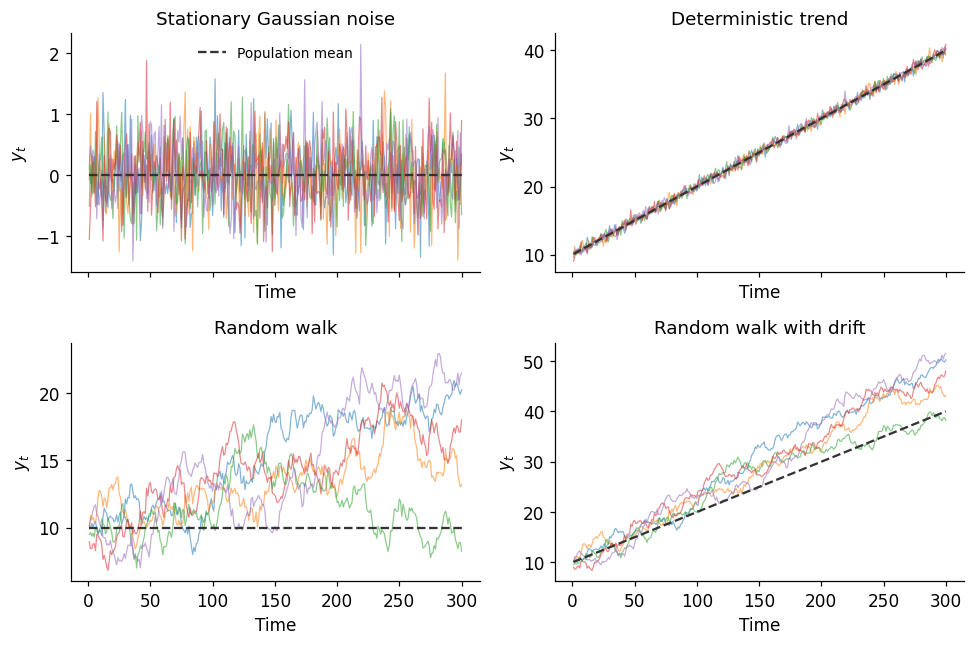

In [2]:
rng_trends = np.random.default_rng(506)
t = np.arange(1, 301)
trend = 10+.1*t
walk_histories = np.array([simulate_random_walk(300, .5, initial=10, rng=rng_trends) for _ in range(5)])
trend_shocks = np.diff(walk_histories, axis=1)
trend_paths = trend+trend_shocks
walk_paths = walk_histories[:, 1:]
fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharex=True)
axes = axes.ravel()
for ax, paths, expectation, title in (
    (axes[0], trend_shocks, np.zeros(300), "Stationary Gaussian noise"),
    (axes[1], trend_paths, trend, "Deterministic trend"),
    (axes[2], walk_paths, np.full(300, 10.), "Random walk"),
    (axes[3], walk_paths+.1*t, 10+.1*t, "Random walk with drift"),
):
    for path in paths:
        ax.plot(t, path, alpha=.55, linewidth=.8)
    ax.plot(t, expectation, "--", color="0.2", linewidth=1.5, label="Population mean")
    ax.set(xlabel="Time", ylabel="$y_t$", title=title)
axes[0].legend(fontsize=9)
fig.tight_layout()
plt.show()

The trend paths fluctuate around a deterministic mean. Random-walk shocks accumulate, so possible histories spread out over time. Removing a deterministic trend and differencing a stochastic trend address different mechanisms. Notebook 10 develops differencing as a modeling procedure.

### Assessing a Unit Root

A plot or one finite sample cannot establish population stationarity. The augmented Dickey–Fuller (ADF) test assesses a particular null: a unit root. With an intercept and no deterministic trend, its regression is
$$\Delta Y_t=\beta_0+\pi Y_{t-1}+\sum_{j=1}^{k}\gamma_j\Delta Y_{t-j}+\varepsilon_t,$$
with $H_0:\pi=0$ against a stationary autoregressive alternative $H_1:\pi<0$. Its reference distribution is not an ordinary Student-t law. The deterministic terms and lag choice must match the question.

For illustration, I compare the first simulated random walk above with its Gaussian increments, using a constant and BIC lag selection. The population construction is known, so the test can be compared with its intended target. Rejection is evidence against this unit-root null, not proof of strict stationarity, finite higher moments or ergodicity.

In [3]:
walk = walk_histories[0]
increments = np.diff(walk)
adf_rows = []
for name, values in [("Random-walk level", walk), ("Gaussian increments", increments)]:
    result = adfuller(values, regression="c", autolag="BIC")
    adf_rows.append({"Series": name, "ADF statistic": result[0], "p-value": result[1],
                     "Selected lag": result[2], "5% critical value": result[4]["5%"]})
display(pd.DataFrame(adf_rows).set_index("Series").round(4))

,ADF statistic,p-value,Selected lag,5% critical value
Series,,,,
Random-walk level,-1.2220,0.6641,0,-2.8712
Gaussian increments,-17.8973,0.0000,0,-2.8713


## 3. Stationary Noise Processes

Noise processes provide basic building blocks for temporal models. Their dependence and distributional assumptions must be distinguished.

### White Noise, IID Noise and Gaussian White Noise

**Definition: white noise.** White noise $Y_t\sim WN(0,\sigma^2)$ requires
$$E[Y_t]=0,\quad\operatorname{Var}(Y_t)=\sigma^2,\quad\operatorname{Cov}(Y_t,Y_{t-j})=0\quad(j\ne0).$$
It imposes zero serial correlation, not independence. **Definition: independent white noise.** IID white noise adds independent, identically distributed observations with those moments. **Definition: Gaussian white noise.** Gaussian white noise adds the common Gaussian law,
$$Y_t\overset{iid}{\sim}N(0,\sigma^2).$$
A Gaussian marginal distribution alone does not establish joint Gaussianity or independence.

### Gaussian Stochastic Processes

**Definition: Gaussian process.** A Gaussian process has a multivariate Gaussian distribution for every finite vector $(Y_{t_1},\ldots,Y_{t_k})$. Its marginal, conditional and linear-combination distributions are Gaussian. For such a process, zero cross-time covariance implies independence. A Gaussian process is not necessarily stationary, but weak stationarity implies strict stationarity for a Gaussian process because its mean and covariance determine every finite-dimensional distribution.

Stationarity does not require constant uncertainty conditional on past observations. The unconditional variance can be stable while conditional variance changes over time, as ARCH/GARCH models in Notebook 09 will show. Independence is a stronger assumption than zero correlation, as in Notebook 02.

### The Wold Representation

Stationary noise provides the building blocks for linear models. The Wold representation explains how a second-order stationary process can be expressed through innovations, with a qualification for any perfectly predictable component.

**Definition: innovation.** An innovation is the error in the best linear prediction of the current value from the entire observed past:
$$\varepsilon_t=X_t-\widehat X^{\mathrm{lin}}_{t\mid t-1}.$$
These errors are orthogonal to past observations and to one another. Under second-order stationarity their variance is constant, so they form $WN(0,\sigma^2)$. Orthogonality does not imply independence or that the best linear predictor equals the conditional expectation.

**Theorem: Wold representation.** For a purely nondeterministic second-order stationary process, the representation is
$$X_t=\mu+\sum_{j=0}^{\infty}\psi_j\varepsilon_{t-j},\qquad
\varepsilon_t\sim WN(0,\sigma^2),\qquad
\psi_0=1,\qquad\sum_{j=0}^{\infty}\psi_j^2<\infty.$$
Here $\mu=E[X_t]$. Square-summability makes the series converge in mean square. The coefficients describe how innovations contribute to the current value.

For a general second-order stationary process, the full decomposition includes a zero-mean, perfectly linearly predictable component $V_t$, orthogonal to the innovation component:
$$X_t=\mu+V_t+\sum_{j=0}^{\infty}\psi_j\varepsilon_{t-j}.$$
“Purely nondeterministic” means that this predictable component is absent. Perfect linear predictability here need not mean that a path is nonrandom. The simpler representation above therefore applies to the purely nondeterministic component; stationarity alone does not eliminate $V_t$.

This provides the common foundation for the linear models in Notebook 08. It does not imply that every stationary process has a finite ARMA representation or independent innovations.


Stationarity describes stable population properties, while the Wold representation supplies a linear-prediction structure. Notebook 08 now introduces specific AR, MA and ARMA models, followed by differencing when modeling non-stationary levels.
